In [1]:
%matplotlib inline
import tempfile
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

import croak
from croak.maths import wlfreq

In [2]:
def make_experiment_file(path):
    # The time window (n*dt = 102 fs) must comfortably exceed the delay range plus
    # the pulse extent, or the gated signal wraps around the periodic FFT window
    # and the "measurement" contains a spurious second copy of the pulse.
    g = croak.Grid(256, dt=0.4e-15)
    omega0 = wlfreq(800e-9)
    ew = croak.gaussian_pulse(g, 6e-15, phases=[25e-30])    # chirped, ~13 fs
    delays = np.linspace(-40e-15, 40e-15, 90)
    trace = croak.maketrace(g.omega, delays, ew, "pg")

    omega_abs = g.omega + omega0
    band = (omega_abs > 0.45 * omega0) & (omega_abs < 2.0 * omega0)
    lam = wlfreq(omega_abs[band])
    order = np.argsort(lam)
    # maketrace returns a *frequency* density I_ω. A spectrometer records a
    # *wavelength* density I_λ = I_ω·|dω/dλ|, and load_and_clean multiplies by
    # λ² to undo exactly that — so convert here, or the Jacobian is applied twice.
    trace_lam = croak.preprocess.omega_to_lambda_density(
        trace[band][order, :], lam[order]
    )
    trace_lam = trace_lam / trace_lam.max()     # detector counts: arbitrary units
    with h5py.File(path, "w") as f:
        f["wavelength"] = lam[order] / 1e-9     # nm
        f["delay"] = delays / 1e-15             # fs
        f["trace"] = trace_lam

    # A real setup also records the fundamental spectrum on its own spectrometer.
    # That is an independent measurement — the retrieval never sees it — so it is
    # the best consistency check available. It is a *wavelength* density, hence
    # the |dw/dl| = 2*pi*c/lambda^2 Jacobian.
    lam_spec = lam[order]
    Ilam_spec = np.abs(ew[band][order]) ** 2 * 2 * np.pi * croak.constants.C / lam_spec**2
    Ilam_spec = Ilam_spec / Ilam_spec.max()

    with h5py.File(path, "a") as f:
        f["spectrum_wavelength"] = lam_spec / 1e-9
        f["spectrum_intensity"] = Ilam_spec

    # Pick the band from the wavelength marginal at 1e-4 of its peak — i.e. the
    # -40 dB point, which is where the signal actually ends on a log plot. A
    # few-percent cut looks generous on a linear scale and badly clips the wings.
    marg = trace_lam.sum(axis=1)
    sig = np.where(marg > 1e-4 * marg.max())[0]
    lam_nm = lam[order] / 1e-9
    # The generating pulse, kept so the tutorial can mark its own homework.
    truth = croak.TruthPulse.from_spectrum(g, ew, omega0)
    return lam_nm[sig[0]] * 1e-9, lam_nm[sig[-1]] * 1e-9, truth

h5_path = str(Path(tempfile.gettempdir()) / "croak_tutorial.h5")
lam_min, lam_max, truth = make_experiment_file(h5_path)
true_fwhm = truth.fwhm
print(f"signal band: {lam_min*1e9:.0f}-{lam_max*1e9:.0f} nm")
print(f"true FWHM  : {true_fwhm/1e-15:.2f} fs   (kept only to check ourselves)")

signal band: 554-1313 nm
true FWHM  : 13.02 fs   (kept only to check ourselves)


In [3]:
fd = croak.io.list_datasets(h5_path)
lam = fd.load("wavelength") * croak.io.unit_to_si("nm")
delays = fd.load("delay") * croak.io.unit_to_si("fs")
trace = fd.load("trace")

# the separately measured fundamental spectrum
lam_spec = fd.load("spectrum_wavelength") * croak.io.unit_to_si("nm")
Ilam_spec = fd.load("spectrum_intensity")
trace.shape, lam_spec.shape

((60, 90), (60,))

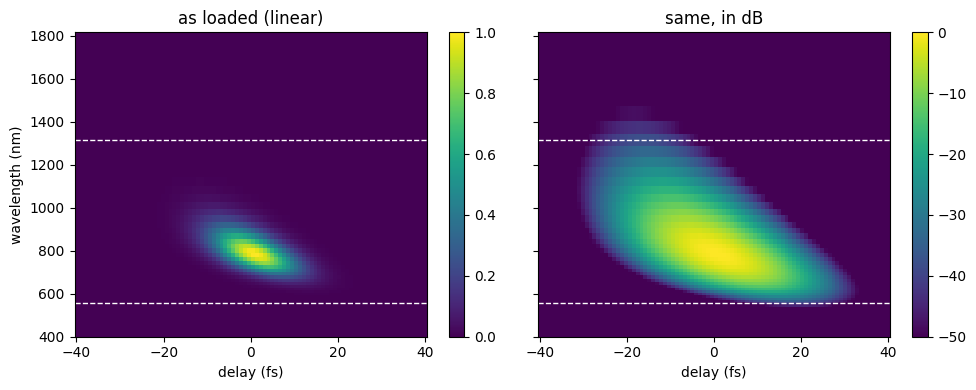

In [4]:
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, data, title in (
    (ax_lin, trace, "as loaded (linear)"),
    (ax_log, 10 * np.log10(np.maximum(trace / trace.max(), 1e-5)), "same, in dB"),
):
    m = ax.pcolormesh(delays * 1e15, lam * 1e9, data, shading="auto",
                      cmap="viridis", vmin=-50 if "dB" in title else None)
    fig.colorbar(m, ax=ax)
    ax.set_xlabel("delay (fs)")
    ax.set_title(title)
    # the chosen band, on *both* panels — the dB one is where you judge it
    ax.axhline(lam_min * 1e9, color="w", ls="--", lw=1)
    ax.axhline(lam_max * 1e9, color="w", ls="--", lw=1)
ax_lin.set_ylabel("wavelength (nm)")
fig.tight_layout()

In [5]:
td = croak.load_and_clean(
    trace, lam, delays, "pg",
    lam_min=lam_min, lam_max=lam_max, input_unit="delay",
    lam_spec=lam_spec, Ilam_spec=Ilam_spec,      # the independent spectrum
)
print(f"regridded trace: {td.trace.shape[0]} freqs × {td.delays.size} delays")
print(f"retrieval grid : {td.grid.n} points, dt = {td.grid.dt / 1e-15:.2f} fs")

regridded trace: 54 freqs × 90 delays
retrieval grid : 54 points, dt = 3.20 fs


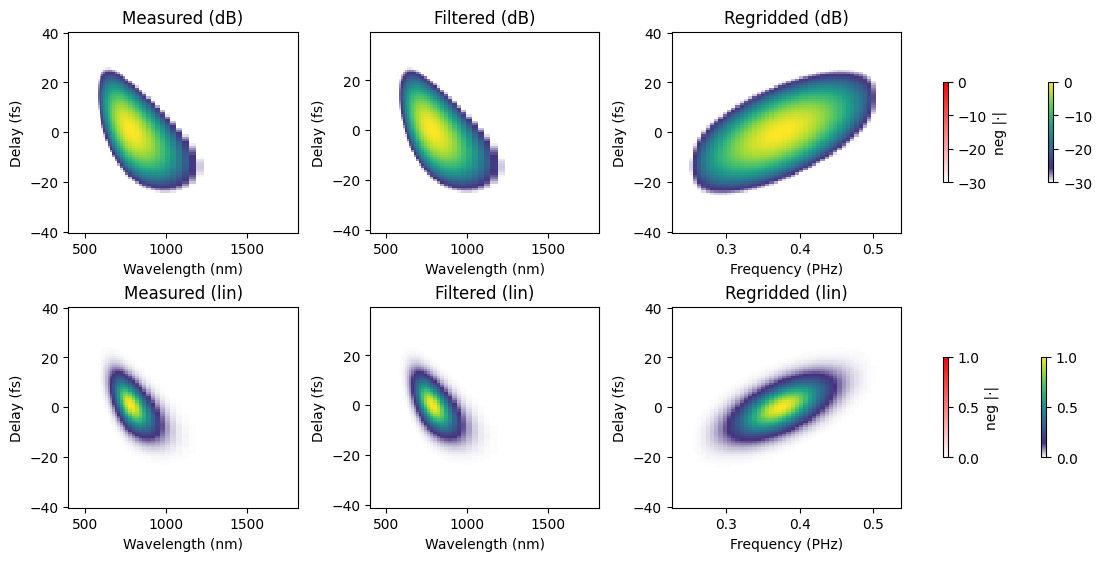

In [6]:
fig = croak.plot_frog_filter(td)
fig.set_size_inches(11, 5.5)
fig

In [7]:
result = croak.retrieve_from_tracedata(td, algorithm="copra", maxiters=250,
                                      rng=np.random.default_rng(0))
print(f"FROG error R = {result.error:.4%}")

FROG error R = 0.0298%


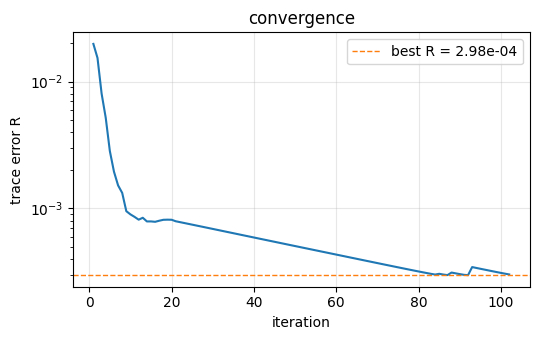

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.semilogy(np.arange(1, len(result.errors) + 1), result.errors)
ax.axhline(result.error, color="C1", ls="--", lw=1,
           label=f"best R = {result.error:.2e}")
ax.set_xlabel("iteration")
ax.set_ylabel("trace error R")
ax.set_title("convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

In [9]:
default = croak.retrieve_from_tracedata(td, rng=np.random.default_rng(0))
print(f"warm-lbfgs (settled regularisation): R = {default.error:.4%}")

warm-lbfgs (settled regularisation): R = 0.0298%


In [10]:
pr = croak.process_result(result, measured=td.trace)
print(f"recovered FWHM = {pr.fwhm_retr / 1e-15:.2f} fs "
      f"(transform-limited {pr.fwhm_tl / 1e-15:.2f} fs)")
print(f"true FWHM      = {true_fwhm / 1e-15:.2f} fs"
      f"   → error {100 * (pr.fwhm_retr - true_fwhm) / true_fwhm:+.1f}%")
print(f"fitted GDD = {pr.gdd_fs2:.0f} fs²,  TOD = {pr.tod_fs3:.0f} fs³"
      f"   (25 fs² went in)")

recovered FWHM = 13.02 fs (transform-limited 6.09 fs)
true FWHM      = 13.02 fs   → error +0.1%
fitted GDD = 25 fs²,  TOD = 0 fs³   (25 fs² went in)


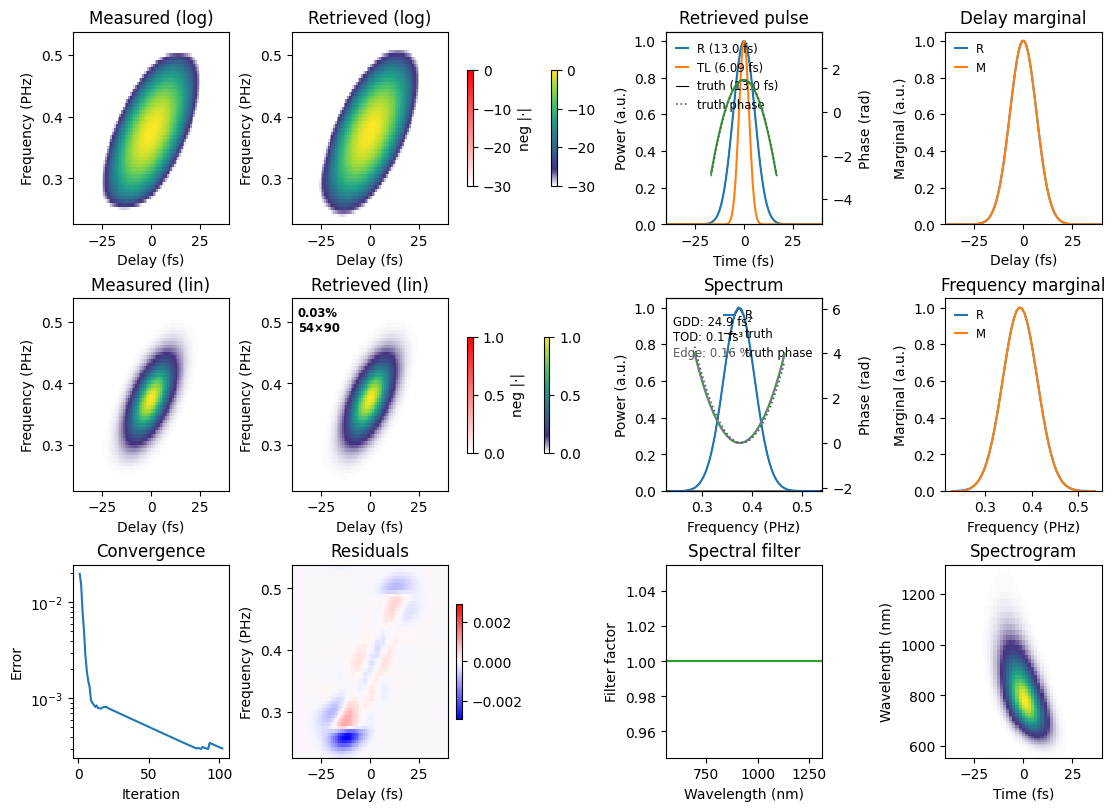

In [11]:
fig = croak.plot_retrieval(result, measured=td.trace, Iomega_meas=td.Iomega,
                          lam_min=td.lam_min, lam_max=td.lam_max,
                          truth=truth, processed=pr)
fig.set_size_inches(11, 8)
fig                                # return the Figure so the notebook displays it

In [12]:
def residual_diagnostics(result, processed, tracedata):
    """Correlate a residual against the shift/scale templates it could arise from."""
    T = result.trace * result.mu
    templates = {
        "delay shift   ∂T/∂τ": np.gradient(T, tracedata.delays, axis=1),
        "freq. shift   ∂T/∂ω": np.gradient(T, tracedata.grid.omega, axis=0),
        "amplitude     T": T,
    }
    a = processed.residual - processed.residual.mean()
    for name, template in templates.items():
        b = template - template.mean()
        c = (a * b).sum() / np.sqrt((a * a).sum() * (b * b).sum())
        print(f"  {name}: {c:+.3f}")

residual_diagnostics(result, pr, td)

  delay shift   ∂T/∂τ: -0.007
  freq. shift   ∂T/∂ω: +0.022
  amplitude     T: +0.066


In [13]:
import dataclasses

step = float(np.diff(td.delays)[0])
shifted = dataclasses.replace(td, delays=td.delays + 0.5 * step)

bad = croak.retrieve_from_tracedata(shifted, algorithm="copra", maxiters=250,
                                    rng=np.random.default_rng(0))
pr_bad = croak.process_result(bad, measured=shifted.trace)
print(f"delay step            = {step / 1e-15:.3f} fs")
print(f"R, correctly centred  = {result.error:.2e}")
print(f"R, offset by half a step = {bad.error:.2e}")
residual_diagnostics(bad, pr_bad, shifted)

delay step            = 0.899 fs
R, correctly centred  = 2.98e-04
R, offset by half a step = 5.10e-03
  delay shift   ∂T/∂τ: -0.534
  freq. shift   ∂T/∂ω: -0.014
  amplitude     T: +0.010


Text(0, 0.5, 'frequency (PHz)')

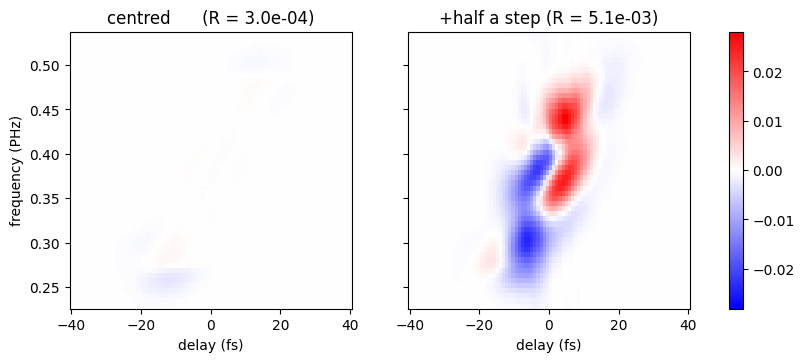

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
vmax = np.abs(pr_bad.residual).max()
for ax, resid, title in (
    (axes[0], pr.residual, f"centred      (R = {result.error:.1e})"),
    (axes[1], pr_bad.residual, f"+half a step (R = {bad.error:.1e})"),
):
    m = ax.pcolormesh(td.delays * 1e15, (td.grid.omega + td.omega0_trace) / (2e15 * np.pi),
                      resid, cmap="bwr", vmin=-vmax, vmax=vmax, shading="auto")
    ax.set_xlabel("delay (fs)")
    ax.set_title(title)
fig.colorbar(m, ax=axes)
axes[0].set_ylabel("frequency (PHz)")

In [15]:
fixed = croak.retrieve_from_tracedata(shifted, algorithm="lm", fit_tau0=True,
                                      maxiters=400, abstol=1e-14,
                                      rng=np.random.default_rng(0))
print(f"fitted τ₀ = {fixed.tau0 / 1e-15:+.3f} fs   (we injected {0.5 * step / 1e-15:+.3f} fs)")
print(f"R         = {fixed.error:.2e}   (back to the centred value)")

fitted τ₀ = +0.449 fs   (we injected +0.449 fs)
R         = 2.95e-04   (back to the centred value)


In [16]:
out = str(Path(tempfile.gettempdir()) / "croak_tutorial_result.h5")
croak.save_result(result, out, processed=pr, force=True)
print("wrote", out)

wrote /var/folders/5f/mptc2lq90gb0lnxmd78k9_lh0000gn/T/croak_tutorial_result.h5
